# 03 - ETL Cleaning and Internal Preparation

External data organization, internal Airbnb data cleaning, parsing, filtering, and internal EDA.

> Split from `PersonaMatch.ipynb` without re-running cells; saved outputs are preserved as stored in the original notebook.


**Organizing and Cleaning External Data:**

In [0]:
from pyspark.sql.functions import lit

# List of all cities
cities = [
    "barcelona", "budapest", "buenos_aires", "cape_town", 
    "lisbon", "mexico_city", "miami", "new_york", 
    "paris", "phuket", "san_francisco", "sau_paulo", 
    "tel_aviv", "tiberias", "tokyo"
]

all_dfs = []

for city in cities:
    file_path = f"{base_path}{city}_final.csv"
    try:
        # 1. loading
        df = (spark.read.format("csv")
              .option("header", "true")
              .option("inferSchema", "true")
              .load(file_path))
        
        # 2. Cleaning up unnecessary columns
        # I added a check so it doesn't crash if the column doesn't exist in one of the cities
        cols_to_drop = ["_c8", "_c9", "_c10", "_c11", "_c12", "_c13", "_c14"]
        df = df.drop(*cols_to_drop)
        
        # 3. City tagging
        display_name = city.replace("_", " ").title()
        df = df.withColumn("source_city", lit(display_name))
        
        all_dfs.append(df)
        print(f"Successfully processed: {display_name}")
        
    except Exception as e:
        print(f"Error processing {city}: {e}")

# 4. Union all cities into one table (instead of the long unionByName)
if all_dfs:
    external_df = all_dfs[0]
    for next_df in all_dfs[1:]:
        external_df = external_df.unionByName(next_df, allowMissingColumns=True)

    print(f"\nTotal rows across all cities: {external_df.count()}")
    display(external_df.limit(10))

Successfully processed: Barcelona
Successfully processed: Budapest
Successfully processed: Buenos Aires
Successfully processed: Cape Town
Successfully processed: Lisbon
Successfully processed: Mexico City
Successfully processed: Miami
Successfully processed: New York
Successfully processed: Paris
Successfully processed: Phuket
Successfully processed: San Francisco
Successfully processed: Sau Paulo
Successfully processed: Tel Aviv
Successfully processed: Tiberias
Successfully processed: Tokyo

Total rows across all cities: 42258


place_name url category rating num_of_reviews reviews_content latitude longitude source_city lat long Manihi Escola de Surf https://www.google.com/maps/place/Manihi+Escola+de+Surf/@41.3874,2.1686,14z/data=!4m11!1m3!2m2!1sSurf+school+in+El+Raval,+Barcelona,+Spain!6e1!3m6!1s0x12a4a3a972c610f5:0x7232cb24a8ba1960!8m2!3d41.3773939!4d2.1904444!15sCilTdXJmIHNjaG9vbCBpbiBFbCBSYXZhbCwgQmFyY2Vsb25hLCBTcGFpblopIidzdXJmIHNjaG9vbCBpbiBlbCByYXZhbCBiYXJjZWxvbmEgc3BhaW6SAQtzdXJmX3NjaG9vbJoBJENoZERTVWhOTUc5blMwVkpRMEZuU1VSR00zTkhkSEpCUlJBQuABAPoBBQiOARAv!16s%2Fg%2F11dzt207cj?hl=en&entry=ttu&g_ep=EgoyMDI2MDEwNy4wIKXMDSoASAFQAw%3D%3D Wellness_Lifestyle 4.6 33 We did the sunrise stand up paddling. It was well organized and overall a great experience. I would totally recommend! || While waking up can be brutal it was worth it to try out SUP at 6 in the morning to see the sun come up. The instructors check on you and give you some pointers if you are new to SUP paddling. 100% recommended. Instructions are in English and Spanish when needed || Highly recommend the sunrise paddleboarding! I joined the group as a solo traveler and had a great time. It's an unforgettable experience, and our guide, Ale, took amazing pictures too! || What a magical experience! I highly recommend a sunrise paddle — such an uplifting and energizing way to start your day. ✨ Ana was lovely, and the photos were fantastic || I came back after a while, the guy welcomed me super nice🩵 (don’t know the name, he was finishing shift) I went for sup, in my humble opinion the board could have more air, nether the less while o got back and gave a feedback 3 boys (fat cats) were smiling and just commenting in Spanish. Well not best experience. Two stars :🌟 for a guy who works there very long and was welcoming me. 🌟 for waves in barceloneta & wind! || Beautiful sunrise SUP ❤️ Ana was a brilliant instructor || One year ago, we experienced a distressing incident at this establishment, where we were unfortunately robbed of our essential belongings such as IDs, cellphones, ATM cards, and more. Picture this: you have an upcoming flight and you've lost the rest of your travel essentials, leaving you stranded and helpless, resembling a beggar without a single possession. This ordeal not only cost us financially but also resulted in the loss of valuable clients who couldn't reach us. And let's not forget the hassle of obtaining new IDs and updating contact information across all our accounts. What happened here, is that the establishment had encouraged us to entrust our smaller bag with valuables to their receiving desk, assuring us it was a safer option than leaving them in their common area. It seemed reasonable, especially as we were heading for a day of surfing, making it impossible to take our important items into the water. However, when our bag went mysteriously missing, their response was astonishingly disappointing. They simply explained that the bag might have been stolen from their receiving desk or perhaps mistakenly handed to another customer. They disclaimed any responsibility for the lost items within their premises. There was no system for securely storing our belongings, all the security cameras were conveniently non-functional, raising suspicions, and the staff exhibited an alarming lack of cooperation and concern for our predicament. To validate this claim, here is a picture of the translated police report. So, is it our mistake to PLACE TRUST in this establishment as their CUSTOMERS? || I booked and PAID for a sunrise paddle on a specific date — only to be told the night before that it was not possible. Instead, they offered Friday as an alternative, a date that didn’t work for me at all. I immediately asked for a refund, and to this day I still haven’t received my €50 back. This is beyond unprofessional, it’s theft. You can’t just take people’s money and disappear. || First time ever on a surfboard and these guys were ace! Gabriel my instructor was a great teacher; the surfb

**Internal Data Preparation: Cleaning, Filtering, and Parsing:**

In [0]:
from pyspark.sql.functions import col, from_json, size, explode, avg, when, flatten, array_distinct
from pyspark.sql.types import ArrayType, StringType, StructType, StructField, DoubleType, IntegerType

# 1. Loading and selecting columns (Selection)
relevant_cols = [
    'listing_name', 'price', 'url', 'image', 'lat', 'long', 
    'description', 'reviews', 'ratings', 'amenities', 
    'category', 'guests', 'pets_allowed', 'is_supperhost', 
    'host_rating', 'property_number_of_reviews', 'highlights', 'house_rules',
    'listing_title', 'location', 'total_price'
]

existing_cols = [c for c in relevant_cols if c in airbnb_df.columns]
internal_df = airbnb_df.select(*existing_cols)

# 2. Cleaning
internal_df = internal_df.dropDuplicates()
internal_df = internal_df.dropna(subset=['listing_name', 'lat', 'long', 'reviews'])

# 3. Type Casting
double_cols = ['price', 'lat', 'long', 'ratings', 'host_rating', 'total_price']
for c in double_cols:
    if c in internal_df.columns:
        internal_df = internal_df.withColumn(c, col(c).cast("double"))

int_cols = ['guests', 'property_number_of_reviews']
for c in int_cols:
    if c in internal_df.columns:
        internal_df = internal_df.withColumn(c, col(c).cast("int"))

# 4. Geographic Filtering:
# Defining the boundaries for each city
city_bounds = {
    "Paris": [48.80, 48.92, 2.20, 2.48],
    "Budapest": [47.40, 47.65, 18.90, 19.35],
    "New York": [40.48, 40.92, -74.26, -73.69],
    "Barcelona": [41.30, 41.47, 2.05, 2.25],
    "Buenos Aires": [-34.71, -34.52, -58.54, -58.33],
    "Sau Paulo": [-23.75, -23.35, -46.85, -46.35],
    "Cape Town": [-34.36, -33.45, 18.30, 19.00],
    "Lisbon": [38.68, 38.80, -9.25, -9.09],
    "Mexico City": [19.10, 19.60, -99.40, -98.90],
    "Miami": [25.70, 25.95, -80.35, -80.10],
    "Phuket": [7.70, 8.25, 98.20, 98.50],
    "San Francisco": [37.70, 37.85, -122.55, -122.35],
    "Tel Aviv": [32.00, 32.15, 34.72, 34.85],
    "Tiberias": [32.75, 32.85, 35.50, 35.60],
    "Tokyo": [35.50, 35.85, 139.50, 140.00]
}

city_column_expr = None

for city, bounds in city_bounds.items():
    lat_min, lat_max, lon_min, lon_max = bounds
    
    # Is the property located within the boundaries of this city?
    is_in_city = (
        (col("lat") > lat_min) & (col("lat") < lat_max) &
        (col("long") > lon_min) & (col("long") < lon_max)
    )
    
    if city_column_expr is None:
        city_column_expr = when(is_in_city, city)
    else:
        city_column_expr = city_column_expr.when(is_in_city, city)

# Update the DataFrame: Add the column and filter rows without city
# Use the same internal_df variable to maintain consistency
internal_df = internal_df.withColumn("source_city", city_column_expr) \
                         .filter(col("source_city").isNotNull())

print(f"Rows after city filtering: {internal_df.count()}")

# 5. Reviews Filtering
if 'property_number_of_reviews' in internal_df.columns:
    internal_df = internal_df.filter(col("property_number_of_reviews") >= 70)

# 6. Parsing & Flattening:
# Defining agreements
amenities_schema = ArrayType(StructType([
    StructField("group_name", StringType(), True),
    StructField("items", ArrayType(StructType([
        StructField("name", StringType(), True),
        StructField("value", StringType(), True)
    ])), True)
]))

highlights_schema = ArrayType(StructType([
    StructField("name", StringType(), True),
    StructField("value", StringType(), True)
]))

reviews_schema = ArrayType(StringType())

# 6.1. Amenities
if 'amenities' in internal_df.columns:
    internal_df = internal_df.withColumn("amenities_struct", from_json(col("amenities"), amenities_schema))
    internal_df = internal_df.withColumn("amenities_list", array_distinct(flatten(col("amenities_struct.items.name"))))

# 6.2. Highlights
if 'highlights' in internal_df.columns:
    internal_df = internal_df.withColumn("highlights_struct", from_json(col("highlights"), highlights_schema))
    internal_df = internal_df.withColumn("highlights_list", col("highlights_struct.name"))

# 6.3. Reviews
if 'reviews' in internal_df.columns:
    internal_df = internal_df.withColumn("reviews", from_json(col("reviews"), reviews_schema))

# 7. Checking the final result
print(f"Final listing count: {internal_df.count()}")
display(internal_df.limit(10))

Rows after city filtering: 90163
Final listing count: 17471


listing_name price url image lat long description reviews ratings amenities category guests pets_allowed is_supperhost host_rating property_number_of_reviews highlights house_rules listing_title location total_price source_city amenities_struct amenities_list highlights_struct highlights_list Entire condo in Miami Beach, Florida, United States null https://www.airbnb.ca/rooms/31239067?currency=USD&guests=1 https://a0.muscache.com/pictures/6836e48f-bf93-4e16-a482-8cab1df7919c.jpg 25.83585 -80.12096 This 16th floor unit is a comfortable 2 bedroom 2 bath beachfront condominium located on the portion of Miami Beach referred to as 'Mid-Beach'. The building is centrally located between North Beach and South Beach making it a perfect location for those desiring a less crowded beach yet close enough for shopping and night life.Guest accessGuests have access to the building’s pool, gym*, and recreation room. Beach lounge chairs are available on the beach on a first come basis.We do not provide refunds for any common amenities that are not available due to circumstances beyond our control due to emergency or maintenance.Other things to notePackage Deliveries:Be informed that, due to the high volume of packages that Valet is receiving, the schedule and procedures have been modified for the benefit of the building Community. Effective Saturday, October 9, 2021. NEW PACKAGE SCHEDULE Monday to Friday from 12 PM to 8 PMSaturdays and Sundays from 8 AM-10 AM and 4 PM-6 PM.**Rates are subject to change**$5.00 per standard size packageLess than thirteen (13) inches.(Any packages where all dimensions, length, width or depth are individually).$10.00 per oversized packageExceeds thirteen (13) inches (Any package where at least one dimension, length, width or depth).Payment Methods-cash or credit card After-hours pick-up fee will be of $25.00Packages not collected within fifteen (15) days will be returned to the carrier, and if the carrier does not accept the return, the Association will dispose of them after ninety (90) days, unless other arrangements are made with Valet. The Association will not accept any responsibility for deliveries of flowers, food, medicines, fragile items, damage or loss of any mail item or any delivery.Registration number002298042017, 2057111 List(Our stay was great overall, but the check-in and first day were very stressful. We arrived at 11 PM with our 10-month-old baby, only to find no keys in the lockbox. There was no phone number to call host, just Airbnb messaging. Thankfully, the building security helped us get a spare key. When we entered the unit we realized it hadn’t been cleaned after the previous guests. Given the late hour, we stayed and used clean sheets we found in the closet to make the beds ourselves. The host responded the next morning and offered a partial refund. A cleaner came at 11 AM but stayed for 5! hours, which made it really difficult to settle in. Despite the rough start, we enjoyed the rest of our stay—the views from the balcony were stunning, the kitchen had everything we needed, and the crib and highchair were a big help with the baby. Having a parking spot (valet-style) was also a big plus for us., 1, this unit was absolutely stunning! clean and comfortable!! my one complaint is that the photos do not demonstrate that the second bedroom is very small and has absolutely no windows, which was inconvenient. Overall, I would recommend this Airbnb but make sure you know it's a bedroom and a half., We stayed last year and enjoyed the condo so decided to stay there again this year. Great value and a great place to stay. Excellent view and beach. Pool heater was not working this year so that was a little disappointing. Also, check in was 3:00 but cleaning lady was in there until about 4:00. Not a big deal. She let us come in and we relaxed on the balcony until she was finished. Overall, great place to stay! If we head to Miami Beach next year, would definitely stay here again., Great stay , can't wai

**Internal Airbnb Data EDA:**

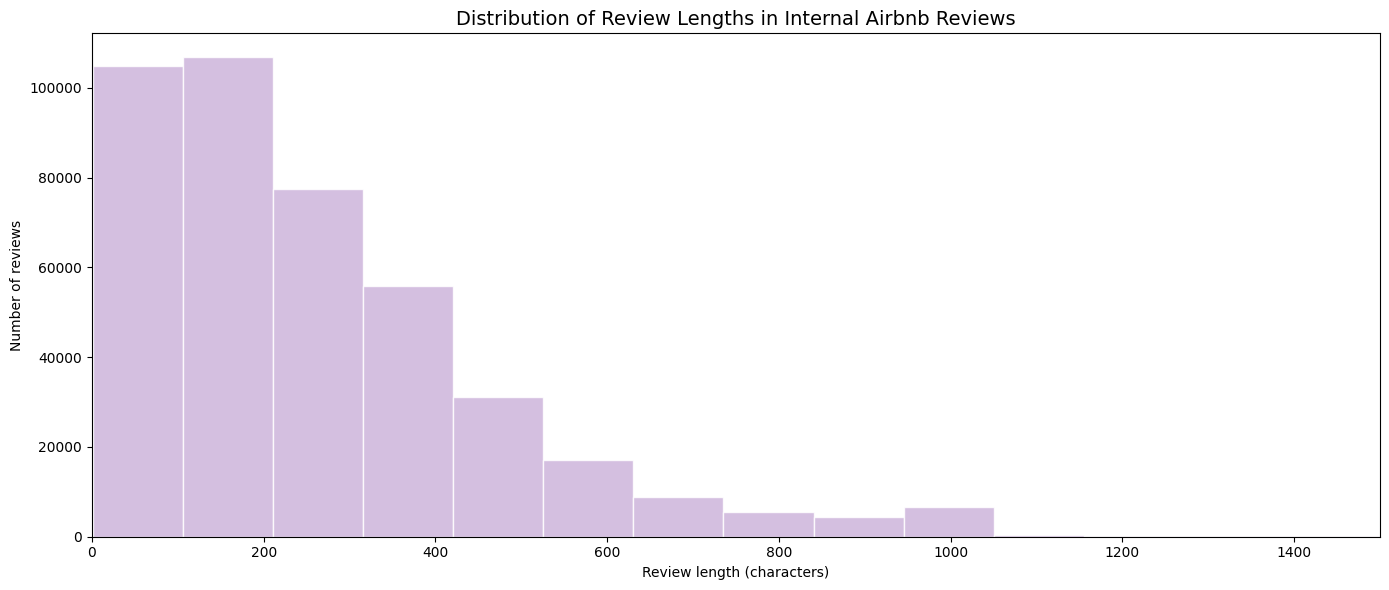

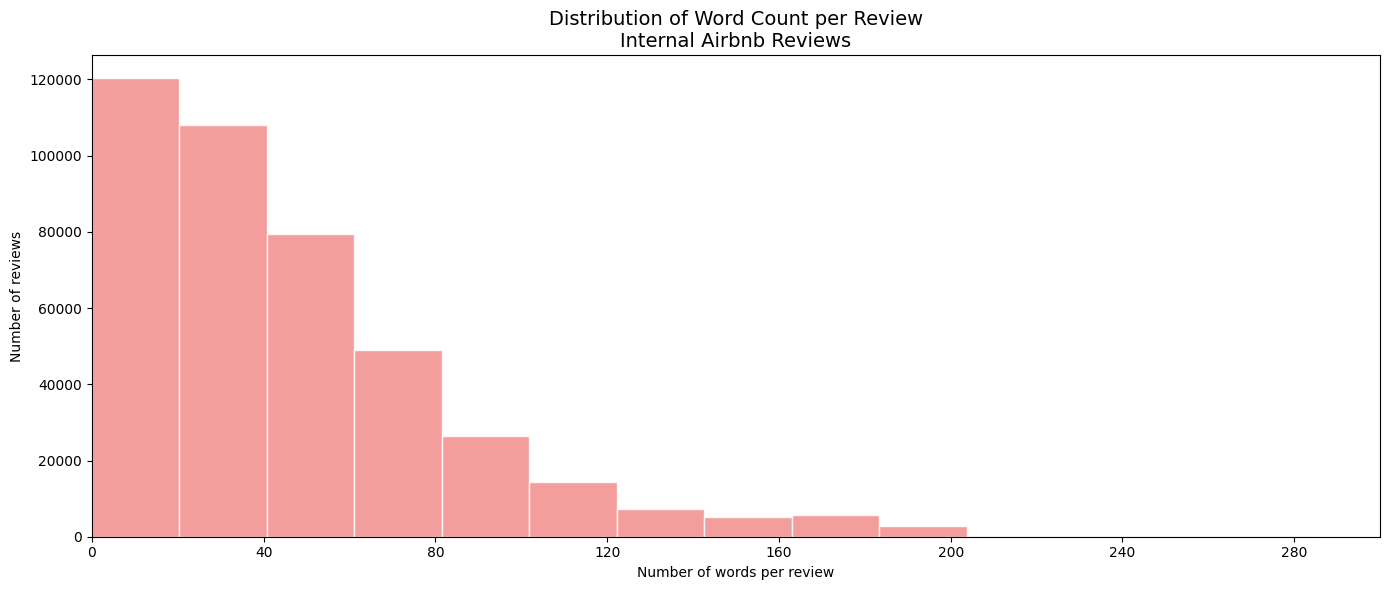

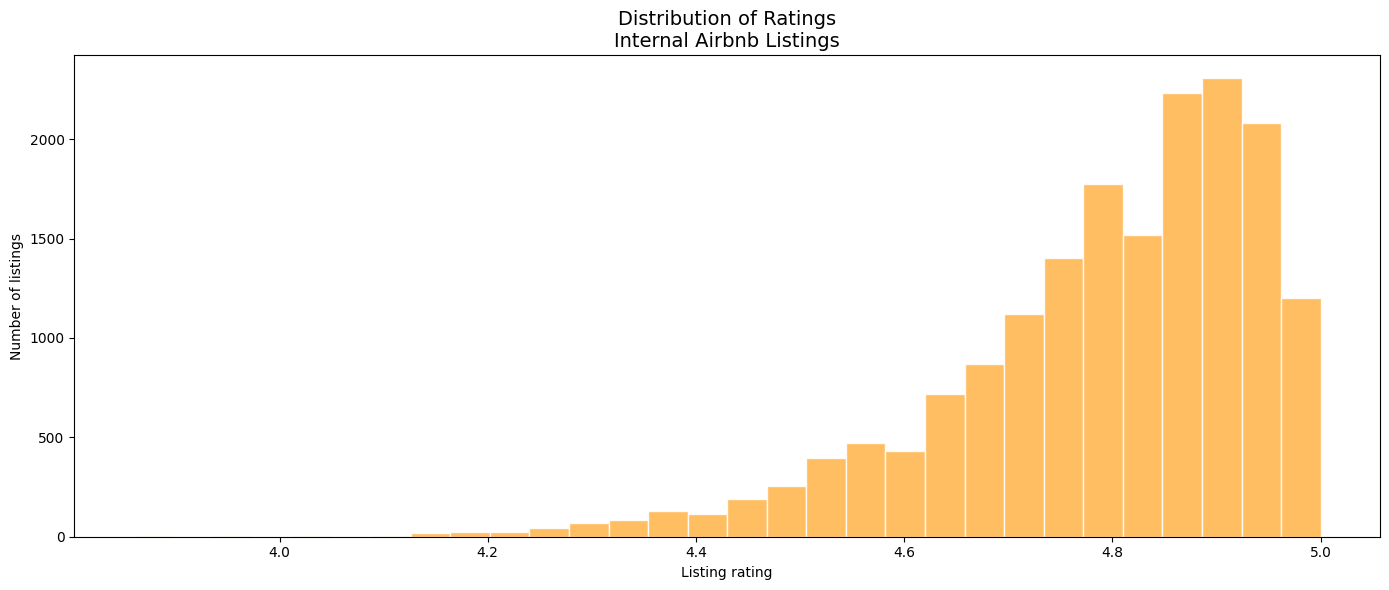

In [0]:
# INTERNAL DATA — EDA
# Airbnb Listings | Reviews, Length, Word Count, Ratings
import re
import numpy as np
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from matplotlib.ticker import MaxNLocator

# 1) Flatten reviews array - one review fer row 
# reviews is an array to explode for text-based EDA
reviews_df = (
    internal_df
    .withColumn("review_text", F.explode_outer("reviews"))
    .filter(F.col("review_text").isNotNull())
)

# 2) Review length (characters)
reviews_df = reviews_df.withColumn(
    "review_length",
    F.length(F.col("review_text"))
)

# 3) Word count per review 
def word_count(text):
    if text is None:
        return 0
    return len(re.findall(r"[a-zA-Z]+", text))

word_count_udf = F.udf(word_count, IntegerType())

reviews_df = reviews_df.withColumn(
    "review_word_count",
    word_count_udf(F.col("review_text"))
)

# 4) Select data for plotting 
pdf_reviews = reviews_df.select(
    "review_length",
    "review_word_count"
).toPandas()

pdf_listings = internal_df.select(
    "property_number_of_reviews",
    "ratings"
).toPandas()

# Graph 1 - Review Length Distribution 
plt.figure(figsize=(14, 6))

plt.hist(
    pdf_reviews["review_length"],
    bins=40,
    color="#CDB4DB",
    alpha=0.85,
    edgecolor="white"
)

plt.xlabel("Review length (characters)")
plt.ylabel("Number of reviews")
plt.title(
    "Distribution of Review Lengths in Internal Airbnb Reviews",
    fontsize=14
)

ax = plt.gca()
ax.set_xlim(0, 1500)
ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

# Graph 2 - word count per review (internal) 
plt.figure(figsize=(14, 6))

plt.hist(
    pdf_reviews["review_word_count"],
    bins=40,
    color="#F28C8C",
    alpha=0.85,
    edgecolor="white"
)

plt.xlabel("Number of words per review")
plt.ylabel("Number of reviews")
plt.title(
    "Distribution of Word Count per Review\nInternal Airbnb Reviews",
    fontsize=14
)

ax = plt.gca()
ax.set_xlim(0, 300)
ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

# Graph 4 — ratings distiburation 
plt.figure(figsize=(14, 6))

plt.hist(
    pdf_listings["ratings"].dropna(),
    bins=30,
    color="#FFB347",
    alpha=0.85,
    edgecolor="white"
)

plt.xlabel("Listing rating")
plt.ylabel("Number of listings")
plt.title(
    "Distribution of Ratings\nInternal Airbnb Listings",
    fontsize=14
)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=8))

plt.tight_layout()
plt.show()